# Density_Estimation(KDE)_EM_algorithm
#### by Qi Pan(Sophie Pan)

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy
import seaborn as sns

In [2]:
n90=pd.read_csv('n90pol.csv')

In [3]:
n90.head()

,amygdala,acc,orientation
0,0.0051,-0.0286,2
1,-0.0674,0.0007,3
2,-0.0257,-0.0110,3
3,0.0504,-0.0167,2
4,0.0125,-0.0005,5


In [4]:
n90.shape

(90, 3)

<AxesSubplot:xlabel='amygdala', ylabel='Count'>

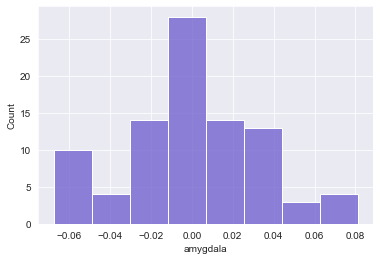

In [5]:
# Plot 1-dimensional hist for amygdala with default setting
sns.set_style('darkgrid')
sns.histplot(data=n90,x='amygdala',color='slateblue')

<AxesSubplot:xlabel='amygdala', ylabel='Count'>

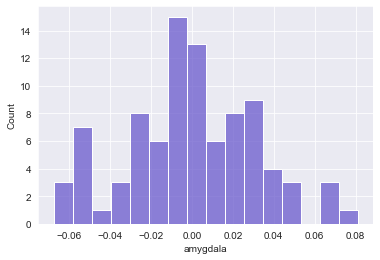

In [6]:
sns.histplot(data=n90,x='amygdala',bins=16,color='slateblue')

<AxesSubplot:xlabel='amygdala', ylabel='Count'>

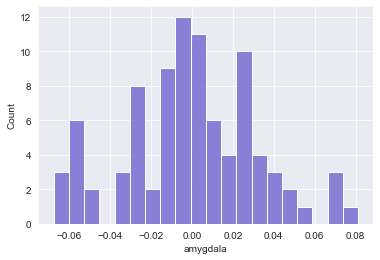

In [7]:
sns.histplot(data=n90,x='amygdala',bins=20,color='slateblue') #I like this one.

<AxesSubplot:xlabel='amygdala', ylabel='Count'>

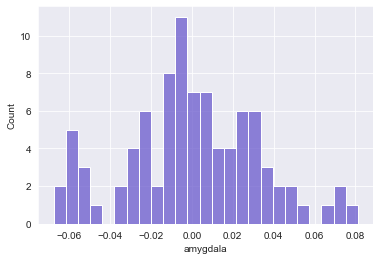

In [8]:
sns.histplot(data=n90,x='amygdala',bins=25,color='slateblue')

<AxesSubplot:xlabel='acc', ylabel='Count'>

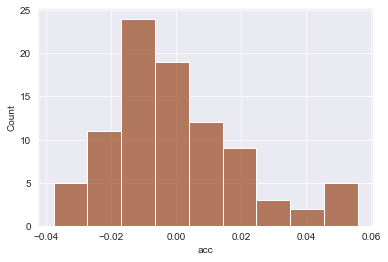

In [9]:
# Plot 1-dimensional hist for acc with default setting
sns.histplot(data=n90,x='acc',color='sienna')

<AxesSubplot:xlabel='acc', ylabel='Count'>

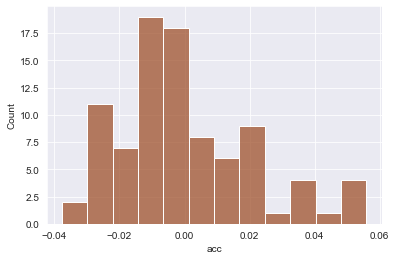

In [10]:
sns.histplot(data=n90,x='acc',bins=12,color='sienna')

<AxesSubplot:xlabel='acc', ylabel='Count'>

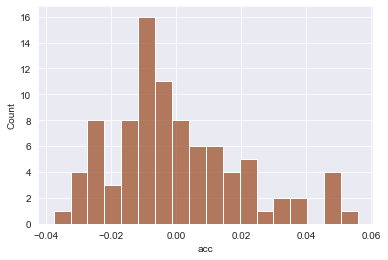

In [11]:
sns.histplot(data=n90,x='acc',bins=18,color='sienna') #I like this one.

<AxesSubplot:xlabel='acc', ylabel='Count'>

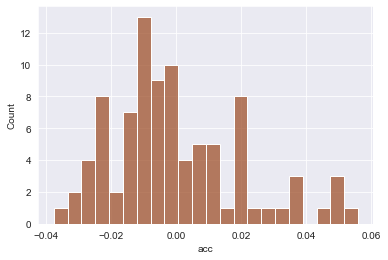

In [12]:
sns.histplot(data=n90,x='acc',bins=22,color='sienna')

Below is how I compare the "Silverman's rule of thumb" in our lecture and the bandwidth value in Seaborn. 

They are infact different. In our lecture, we multiply the std of our data to $1.06*m^{-1/5}$. 
So in lecture: $h=std*1.06*m^{-1/5}$

However, in Seaborn and Scipy packages, they just ignore the std and end with: 
$h=(m * (d + 2) / 4)**(-1 / (d + 4))$

BTW, Seaborn and Scipy's ways of calculation bandwidth are the same!

In [13]:
#try to calculate the best bandwidth for amygdala with rule of thumb

best_h_lecture=1.06*np.std(n90['amygdala'])*(len(n90)**(-0.2))
best_h_lecture

0.013973984566878189

In [14]:
scipy.stats.gaussian_kde(n90['amygdala'], bw_method='silverman').factor * np.std(n90['amygdala']) 

0.013963752460080695

From above, we can tell the values are the same!

In [15]:
#best bandwidth for amygdala in Scipy/Seaborn
scipy.stats.gaussian_kde(n90['amygdala'], bw_method='silverman').factor

0.4306646699852111

In [16]:
#best bandwidth for acc in Scipy/Seaborn
scipy.stats.gaussian_kde(n90['acc'], bw_method='silverman').factor

0.4306646699852111

### Start plotting

<AxesSubplot:xlabel='amygdala', ylabel='Density'>

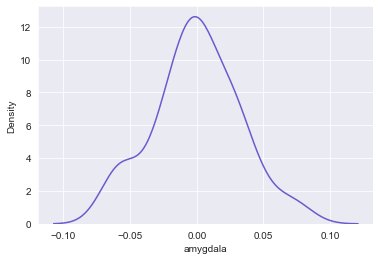

In [17]:
#Plot 1-dimensional KDE for amygdala with default setting
sns.kdeplot(data=n90,x='amygdala',color='slateblue')

<AxesSubplot:xlabel='amygdala', ylabel='Density'>

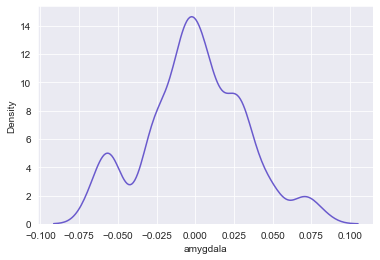

In [18]:
sns.kdeplot(data=n90,x='amygdala',bw_adjust=0.6,color='slateblue')# I like this one.

<AxesSubplot:xlabel='amygdala', ylabel='Density'>

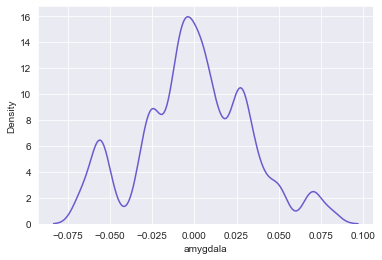

In [19]:
sns.kdeplot(data=n90,x='amygdala',bw_adjust=0.4,color='slateblue')

<AxesSubplot:xlabel='amygdala', ylabel='Density'>

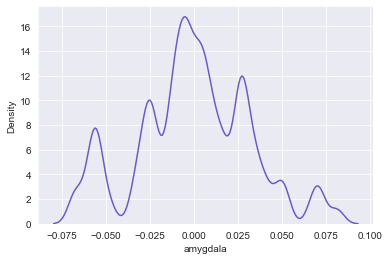

In [20]:
sns.kdeplot(data=n90,x='amygdala',bw_adjust=0.3,color='slateblue')

<AxesSubplot:xlabel='acc', ylabel='Density'>

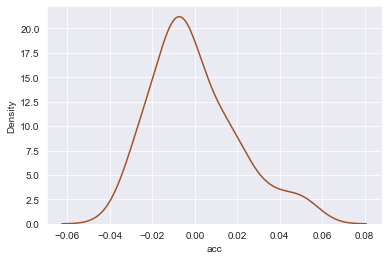

In [21]:
#Plot 1-dimensional KDE for acc with default setting
sns.kdeplot(data=n90,x='acc',color='sienna') #I like this default one the best.

<AxesSubplot:xlabel='acc', ylabel='Density'>

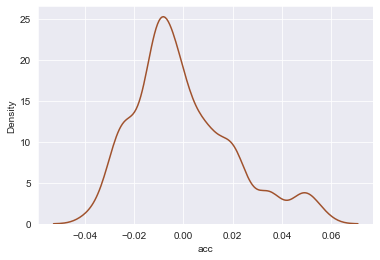

In [22]:
sns.kdeplot(data=n90,x='acc',bw_adjust=0.6,color='sienna')

<AxesSubplot:xlabel='acc', ylabel='Density'>

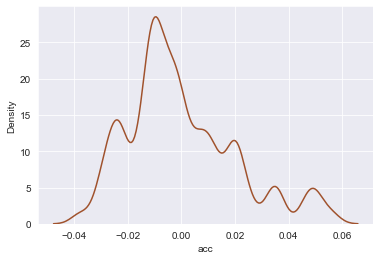

In [23]:
sns.kdeplot(data=n90,x='acc',bw_adjust=0.4,color='sienna')

<AxesSubplot:xlabel='acc', ylabel='Density'>

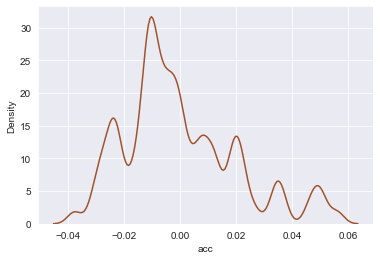

In [24]:
sns.kdeplot(data=n90,x='acc',bw_adjust=0.3,color='sienna')

### 2-dimensional histogram for amygdala, acc

<AxesSubplot:xlabel='amygdala', ylabel='acc'>

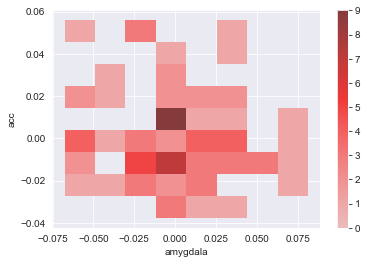

In [25]:
sns.histplot(data=n90, x='amygdala',y='acc',color="firebrick",cbar=True)

<AxesSubplot:xlabel='amygdala', ylabel='acc'>

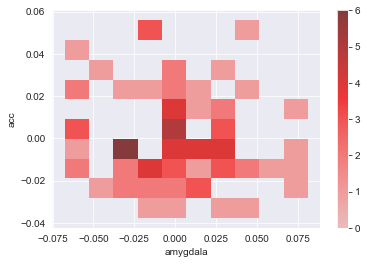

In [26]:
sns.histplot(data=n90, x='amygdala',y='acc',color="firebrick",bins=10,cbar=True)

<AxesSubplot:xlabel='amygdala', ylabel='acc'>

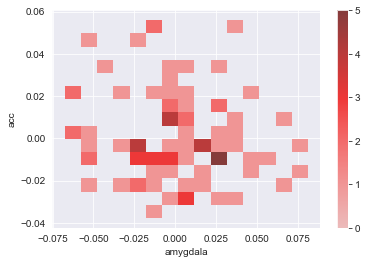

In [27]:
# When bin=15, there are many bins empty. So sparse. This is exactly what prof X said in the lecture!
sns.histplot(data=n90, x='amygdala',y='acc',color="firebrick",bins=15,cbar=True)

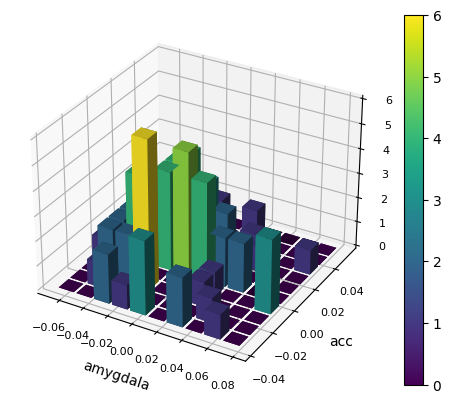

In [28]:
from matplotlib.colors import Normalize
from matplotlib import cm

plt.style.use('default')
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
#hist is the count in 2d array, xedges, yedges are the position of each bar
hist, xedges, yedges = np.histogram2d(n90['amygdala'], n90['acc'], bins=10)

# Construct arrays for the positions of the bars
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1])
xpos=xpos.ravel()
ypos=ypos.ravel()
zpos = np.zeros_like (xpos) # z coordinate always start from 0
#size of each bar=dx,dy,dz
dx = 0.85*(xedges [1] - xedges [0]) # shrink the thickness so we can see clear each bar
dy = 0.85*(yedges [1] - yedges [0])
dz = hist.flatten()
cmap = cm.get_cmap('viridis')
norm = Normalize(vmin=min(dz), vmax=max(dz))
colors = cmap(norm(dz))

ax.bar3d(xpos, ypos, zpos, dx, dy, dz,color=colors)
ax.tick_params(labelsize=8) #调节刻度文字大小
ax.set_xlabel('amygdala')
ax.set_ylabel('acc')
sc = cm.ScalarMappable(cmap=cmap,norm=norm)
sc.set_array([])
plt.colorbar(sc)

### 2-dimensional KDE for amygdala, acc

<AxesSubplot:xlabel='amygdala', ylabel='acc'>

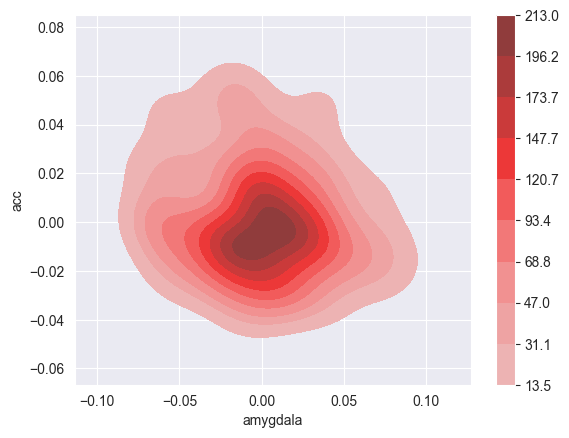

In [29]:
sns.set_style('darkgrid')
#default of bandwidth
sns.kdeplot(data=n90, x='amygdala',y='acc',color="firebrick",fill=True,cbar=True)

<AxesSubplot:xlabel='amygdala', ylabel='acc'>

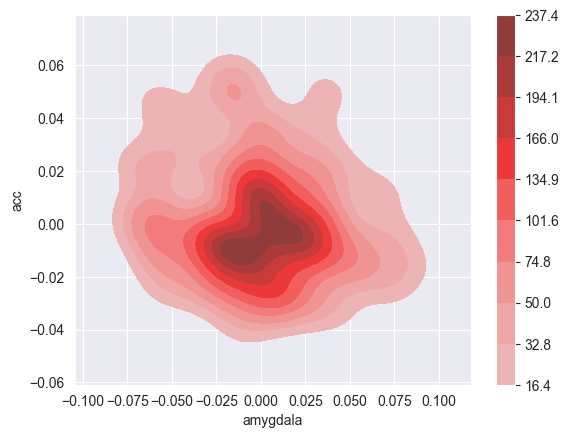

In [30]:
sns.kdeplot(data=n90, x='amygdala',y='acc',color="firebrick",bw_adjust=0.8,fill=True,cbar=True)

<AxesSubplot:xlabel='amygdala', ylabel='acc'>

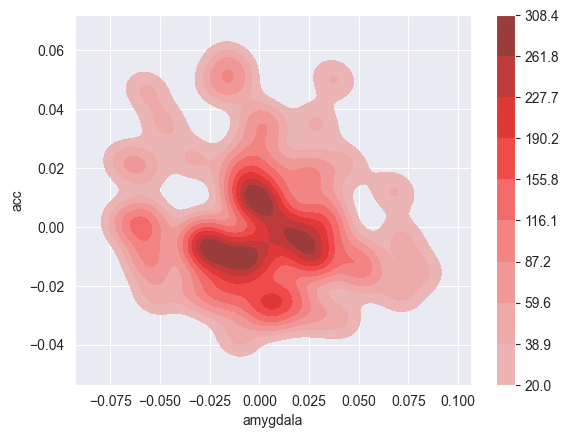

In [31]:
sns.kdeplot(data=n90, x='amygdala',y='acc',color="firebrick",bw_adjust=0.55,fill=True,cbar=True)

In [32]:
# Try hand calculate the KED plot
min_data = np.array(n90[['amygdala','acc']]).min(axis=0)
max_data = np.array(n90[['amygdala','acc']]).max(axis=0)
gridno = 40
inc1 = (max_data[0]-min_data[0])/gridno # for 'amygdala'
inc2 = (max_data[1]-min_data[1])/gridno # for 'acc'
gridx, gridy = np.meshgrid(np.arange(min_data[0],max_data[0]+inc1,inc1), np.arange(min_data[1],max_data[1]+inc2,inc2))
gridall = [gridx.flatten(order = 'F'), gridy.flatten(order = 'F')] 
#msehgrid输出网格的坐标是2维，gridall前面是x轴扯平，后面是y轴扯平，每一列是一个坐标点
gridall = (np.asarray(gridall)).T #转置以后，每一个row是一个坐标点，瘦长
gridallno, nn= gridall.shape #gridallno=一共几个坐标，nn=2=每个坐标是2维的x,y构成

norm_pdata = (np.power(np.array(n90[['amygdala','acc']]), 2)).sum(axis=1) #列向量，||x^i||^2 再求和=1个scalar=90个
norm_gridall = (np.power(gridall, 2)).sum(axis=1) #列向量，||x||^2=每个xy平面上的坐标网格点的norm 2的平方再求和=1722个
cross = gridall@np.array(n90[['amygdala','acc']]).T #瘦长的gridall （1722*2）@ 胖矮的xi矩阵，（2*90）=1722*90
#cross.T: 转置以后是每row=同样的样本xi对于不用的grid=列数
print(np.array(n90[['amygdala','acc']]).T.shape)
print(gridall.shape)
print('norm_pdata size is',norm_pdata.shape)
print(norm_gridall.shape)
print(cross.shape)

(2, 90)
(1722, 2)
norm_pdata size is (90,)
(1722,)
(1722, 90)


In [33]:
# compute squared distance between each data point and the grid point;
#gridallno=1722
#下面的norm_pdata repeat以后是每个数重复1722次的array，每个row 的组成元素数字都一样=||x^i||^2 ,向下排90次
dist2 = np.repeat(norm_pdata, repeats =gridallno).reshape((90, gridallno))+\
np.tile(norm_gridall, 90).reshape((90, gridallno)) - 2* cross.T
#上面的norm_gridall tile以后形成90*1772矩阵，每一行都是1772个，但是value不一样，是all grid的||x||^2

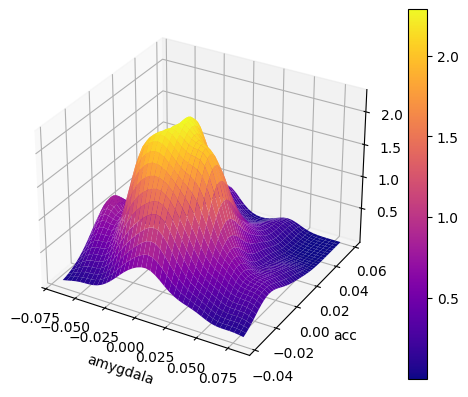

In [34]:
bandwidth = 0.01
#evaluate the kernel function value for each training data point and grid
kernelvalue =(0.5/(np.pi*bandwidth))*np.exp(-dist2/(2*bandwidth**2))

mkde = sum(kernelvalue) / 90 #按照axis=0叠加，变成长度=1722的array，再/m求均=p(x)
#reshape back to grid;
mkde = ((mkde.T).reshape(gridx.shape[1], gridx.shape[0])).T

plt.style.use('default')
fig = plt.figure()

ax=fig.add_subplot(111, projection='3d')
ax.plot_surface(gridx, gridy, mkde,cmap=plt.cm.plasma)
ax.set_xlabel('amygdala')
ax.set_ylabel('acc')
#ax.view_init(30, 40) # rotate the view point
k = cm.ScalarMappable(cmap=cm.plasma)
k.set_array(mkde)
plt.colorbar(k)

### Check whether there is outlier

((array([-2.42415376, -2.08314654, -1.88544094, -1.74203229, -1.6274797 ,
         -1.53100677, -1.44698836, -1.37209892, -1.30420086, -1.24183466,
         -1.18395713, -1.12979528, -1.07875949, -1.03038903, -0.98431657,
         -0.94024414, -0.89792636, -0.85715854, -0.81776789, -0.77960706,
         -0.74254919, -0.70648412, -0.67131546, -0.63695823, -0.60333702,
         -0.57038445, -0.53803999, -0.50624894, -0.47496157, -0.44413245,
         -0.41371985, -0.38368524, -0.35399289, -0.32460945, -0.29550368,
         -0.26664617, -0.23800906, -0.20956586, -0.18129123, -0.15316082,
         -0.12515112, -0.09723927, -0.069403  , -0.04162041, -0.01386991,
          0.01386991,  0.04162041,  0.069403  ,  0.09723927,  0.12515112,
          0.15316082,  0.18129123,  0.20956586,  0.23800906,  0.26664617,
          0.29550368,  0.32460945,  0.35399289,  0.38368524,  0.41371985,
          0.44413245,  0.47496157,  0.50624894,  0.53803999,  0.57038445,
          0.60333702,  0.63695823,  0.

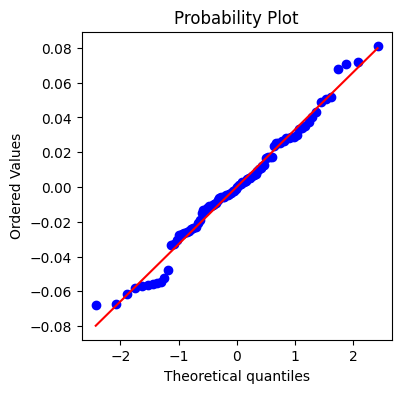

In [35]:
import pylab
plt.figure(figsize=(4,4))
scipy.stats.probplot(n90['amygdala'],dist="norm", plot=pylab)

((array([-2.42415376, -2.08314654, -1.88544094, -1.74203229, -1.6274797 ,
         -1.53100677, -1.44698836, -1.37209892, -1.30420086, -1.24183466,
         -1.18395713, -1.12979528, -1.07875949, -1.03038903, -0.98431657,
         -0.94024414, -0.89792636, -0.85715854, -0.81776789, -0.77960706,
         -0.74254919, -0.70648412, -0.67131546, -0.63695823, -0.60333702,
         -0.57038445, -0.53803999, -0.50624894, -0.47496157, -0.44413245,
         -0.41371985, -0.38368524, -0.35399289, -0.32460945, -0.29550368,
         -0.26664617, -0.23800906, -0.20956586, -0.18129123, -0.15316082,
         -0.12515112, -0.09723927, -0.069403  , -0.04162041, -0.01386991,
          0.01386991,  0.04162041,  0.069403  ,  0.09723927,  0.12515112,
          0.15316082,  0.18129123,  0.20956586,  0.23800906,  0.26664617,
          0.29550368,  0.32460945,  0.35399289,  0.38368524,  0.41371985,
          0.44413245,  0.47496157,  0.50624894,  0.53803999,  0.57038445,
          0.60333702,  0.63695823,  0.

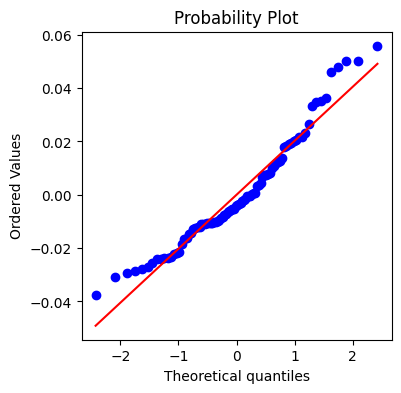

In [36]:
plt.figure(figsize=(4,4))
scipy.stats.probplot(n90['acc'],dist="norm", plot=pylab)

In [37]:
# Tukey's rule of amygdala
IQR_amygdala=scipy.stats.iqr(n90['amygdala']) # no need to sort our data array
Q1_amygdala=np.quantile(n90['amygdala'],0.25)
Q3_amygdala=np.quantile(n90['amygdala'],0.75)
lower_bound=Q1_amygdala-1.5*IQR_amygdala
upper_bound=Q3_amygdala+1.5*IQR_amygdala
lower_outlier=np.sum(n90['amygdala']<lower_bound)
upper_outlier=np.sum(n90['amygdala']>upper_bound)
print(f'There are total {lower_outlier} amygdala data point less than the lower bound of \
the Tukey’s rule.')
print(f'There are total {upper_outlier} amygdala data point bigger than the upper bound of \
the Tukey’s rule.')

There are total 0 amygdala data point less than the lower bound of the Tukey’s rule.
There are total 0 amygdala data point bigger than the upper bound of the Tukey’s rule.


In [38]:
# Tukey's rule of acc
IQR_acc=scipy.stats.iqr(n90['acc']) # no need to sort our data array
Q1_acc=np.quantile(n90['acc'],0.25)
Q3_acc=np.quantile(n90['acc'],0.75)
lower_bound=Q1_acc-1.5*IQR_acc
upper_bound=Q3_acc+1.5*IQR_acc
lower_outlier=np.sum(n90['acc']<lower_bound)
upper_outlier=np.sum(n90['acc']>upper_bound)
print(f'There are total {lower_outlier} acc data point less than the lower bound of \
the Tukey’s rule.')
print(f'There are total {upper_outlier} acc data points bigger than the upper bound of \
the Tukey’s rule.')

There are total 0 acc data point less than the lower bound of the Tukey’s rule.
There are total 4 acc data points bigger than the upper bound of the Tukey’s rule.


### Judge whether amygdala and acc are independent or not

In [39]:
# Calculate the marginal probability 
amygdala_kdepdf=scipy.stats.gaussian_kde(n90['amygdala'], bw_method=0.6)
acc_kdepdf=scipy.stats.gaussian_kde(n90['acc'], bw_method=0.6)

prob_amy=amygdala_kdepdf(gridx[0,:]) #这个出的不是概率,是density！但是积分以后会cancel x,y,xy
prob_acc=acc_kdepdf(gridy[:,1])
print(prob_amy)

[ 2.50210922  2.85375635  3.20520129  3.55964705  3.92568476  4.31604341
  4.74518567  5.22616913  5.76738116  6.36979547  7.02528897  7.71634071
  8.41717484  9.09616432  9.71912173 10.25298004 10.66931625 10.94719536
 11.07491976 11.05045803 10.88057599 10.57895167 10.16375455  9.65524444
  9.07386653  8.43910934  7.76912207  7.08085046  6.39032423  5.71274958
  5.06220513  4.45094582  3.88850606  3.38089697  2.93018384  2.53462256
  2.18937168  1.88763595  1.62198785  1.38558291  1.17303361]


In [40]:
print(gridx.shape)
gridx

(42, 41)


array([[-0.0676 , -0.06388, -0.06016, ...,  0.07376,  0.07748,  0.0812 ],
       [-0.0676 , -0.06388, -0.06016, ...,  0.07376,  0.07748,  0.0812 ],
       [-0.0676 , -0.06388, -0.06016, ...,  0.07376,  0.07748,  0.0812 ],
       ...,
       [-0.0676 , -0.06388, -0.06016, ...,  0.07376,  0.07748,  0.0812 ],
       [-0.0676 , -0.06388, -0.06016, ...,  0.07376,  0.07748,  0.0812 ],
       [-0.0676 , -0.06388, -0.06016, ...,  0.07376,  0.07748,  0.0812 ]])

In [41]:
print(gridy.shape)
gridy

(42, 41)


array([[-0.0377 , -0.0377 , -0.0377 , ..., -0.0377 , -0.0377 , -0.0377 ],
       [-0.03536, -0.03536, -0.03536, ..., -0.03536, -0.03536, -0.03536],
       [-0.03302, -0.03302, -0.03302, ..., -0.03302, -0.03302, -0.03302],
       ...,
       [ 0.05356,  0.05356,  0.05356, ...,  0.05356,  0.05356,  0.05356],
       [ 0.0559 ,  0.0559 ,  0.0559 , ...,  0.0559 ,  0.0559 ,  0.0559 ],
       [ 0.05824,  0.05824,  0.05824, ...,  0.05824,  0.05824,  0.05824]])

In [42]:
pdf_amy=amygdala_kdepdf(gridx[0,:]).reshape((41,1)) #col vector=41*1
pdf_acc=acc_kdepdf(gridy[:,0]).reshape((42,1)) #col vector=42*1
margin_pdf=(pdf_amy@pdf_acc.T).T #42*41

In [43]:
# Calculate the joint probability 
joint_kdepdf=scipy.stats.gaussian_kde(np.array(n90[['amygdala','acc']]).T,bw_method=0.6) #bw_method='silverman'
#算kde的data维度只可以一行一行排，每行是一个variable

In [44]:
positions=np.vstack([gridx.ravel(),gridy.ravel()])
joint_pdf=joint_kdepdf(positions).reshape((42,41))
joint_pdf.shape

(42, 41)

<AxesSubplot:>

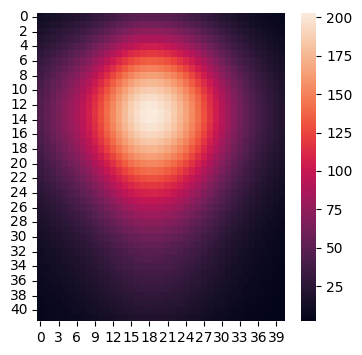

In [45]:
plt.figure(figsize=(4,4))
sns.heatmap(margin_pdf)

<AxesSubplot:>

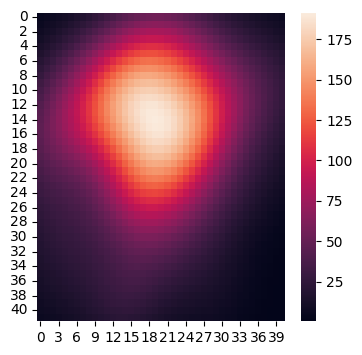

In [46]:
plt.figure(figsize=(4,4))
sns.heatmap(joint_pdf)

<AxesSubplot:>

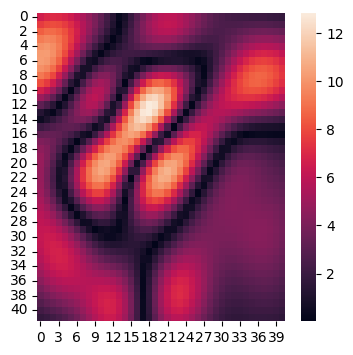

In [47]:
#plot the different between the joint and margin probability
plt.figure(figsize=(4,4))
sns.heatmap(np.abs(margin_pdf-joint_pdf))

### conditional distribution with  orientation from 2~5

In [48]:
np.unique(n90['orientation'])

array([2, 3, 4, 5])

[Text(0.5, 0, 'amygdala, c=5')]

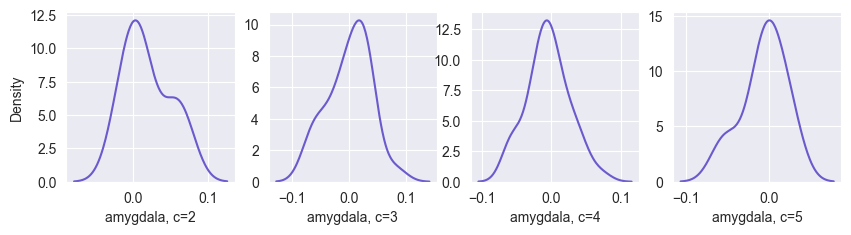

In [49]:
mask2=n90['orientation']==2
mask3=n90['orientation']==3
mask4=n90['orientation']==4
mask5=n90['orientation']==5
sns.set_style('darkgrid')
fig, axe = plt.subplots(1,4)
fig.set_size_inches([10,2.2])

sns.kdeplot(x=n90['amygdala'][mask2],color='slateblue',ax=axe[0])
sns.kdeplot(x=n90['amygdala'][mask3],color='slateblue',ax=axe[1])
sns.kdeplot(x=n90['amygdala'][mask4],color='slateblue',ax=axe[2])
sns.kdeplot(x=n90['amygdala'][mask5],color='slateblue',ax=axe[3])
axe[1].set(ylabel=None)
axe[2].set(ylabel=None)
axe[3].set(ylabel=None)
axe[0].set(xlabel='amygdala, c=2')
axe[1].set(xlabel='amygdala, c=3')
axe[2].set(xlabel='amygdala, c=4')
axe[3].set(xlabel='amygdala, c=5')
#Just use auto bandwidth is good enough.

[Text(0.5, 0, 'acc, c=5')]

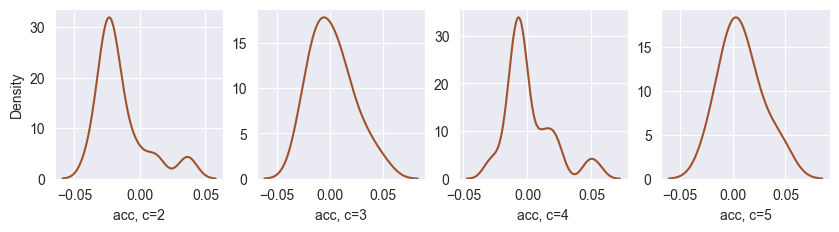

In [50]:
fig, axe = plt.subplots(1,4)
fig.set_size_inches([10,2.2])

sns.kdeplot(x=n90['acc'][mask2],color='sienna',ax=axe[0],bw_adjust=0.6)
sns.kdeplot(x=n90['acc'][mask3],color='sienna',ax=axe[1])
sns.kdeplot(x=n90['acc'][mask4],color='sienna',ax=axe[2],bw_adjust=0.6)
sns.kdeplot(x=n90['acc'][mask5],color='sienna',ax=axe[3])
axe[1].set(ylabel=None)
axe[2].set(ylabel=None)
axe[3].set(ylabel=None)
axe[0].set(xlabel='acc, c=2')
axe[1].set(xlabel='acc, c=3')
axe[2].set(xlabel='acc, c=4')
axe[3].set(xlabel='acc, c=5')
#I have tried to adjust the bandwidth and seems for c=2 and 4, bw=0.6 is good. 
#For c=3 and 5, just use auto bandwidth is good enough.

In [51]:
# conditional sample mean for amygdala
for i in range(4):
    mask=n90['orientation']==i+2
    print(np.mean(n90['amygdala'][mask]))

0.01906153846153846
0.0005875000000000013
-0.004719512195121951
-0.005691666666666667


In [52]:
# conditional sample mean for acc
for i in range(4):
    mask=n90['orientation']==i+2
    print(np.mean(n90['acc'][mask]))

-0.014769230769230767
0.0016708333333333338
0.001309756097560975
0.008141666666666667


### conditional joint distribution with  orientation from 2~5

[Text(0.5, 1.0, 'c = 3, bandwidth=0.80')]

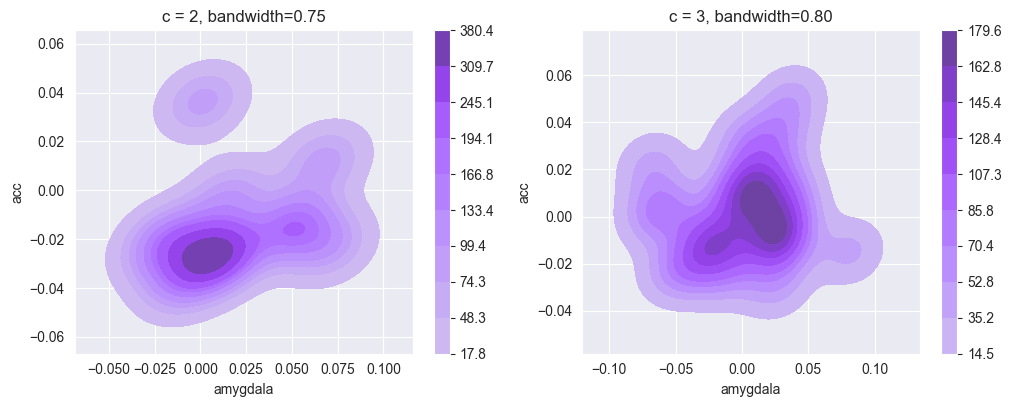

In [53]:
fig, axe = plt.subplots(1,2)
fig.set_size_inches([12,4.2])

sns.kdeplot(data=n90[mask2],x='amygdala',y='acc',color="indigo",bw_adjust=0.75,fill=True,cbar=True,ax=axe[0])
sns.kdeplot(data=n90[mask3],x='amygdala',y='acc',color="indigo",bw_adjust=0.8,fill=True,cbar=True,ax=axe[1])
axe[0].set(title='c = 2, bandwidth=0.75')
axe[1].set(title='c = 3, bandwidth=0.80')

[Text(0.5, 1.0, 'c = 5, bandwidth=0.90')]

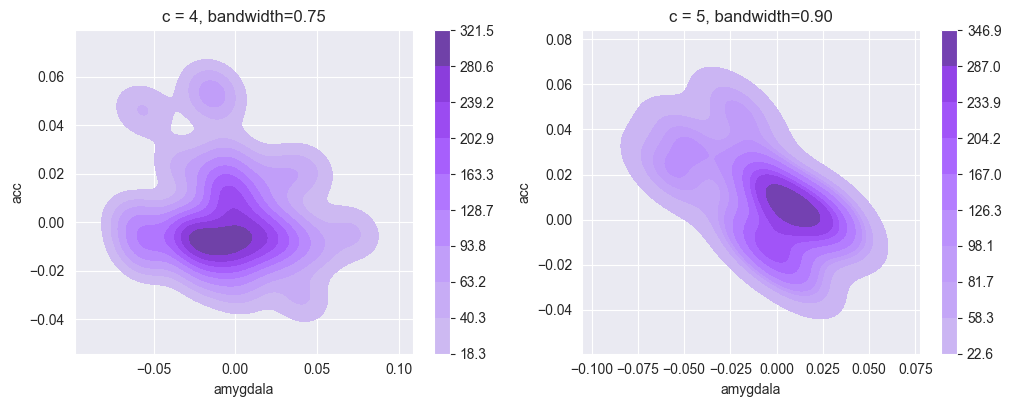

In [54]:
fig, axe = plt.subplots(1,2)
fig.set_size_inches([12,4.2])

sns.kdeplot(data=n90[mask4],x='amygdala',y='acc',color="indigo",bw_adjust=0.75,fill=True,cbar=True,ax=axe[0])
sns.kdeplot(data=n90[mask5],x='amygdala',y='acc',color="indigo",bw_adjust=0.9,fill=True,cbar=True,ax=axe[1])
axe[0].set(title='c = 4, bandwidth=0.75')
axe[1].set(title='c = 5, bandwidth=0.90')

The plots for different orientation look different. Seems there is a difference between brain structure and political view!


## Implement EM algorithm

In [55]:
mnist=sio.loadmat('data.mat')

In [56]:
mnist=mnist['data'] #each col is a picture with 1990 pictures
print(mnist.shape)
mnist

(784, 1990)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

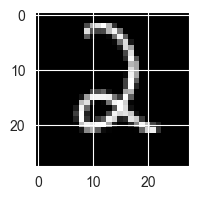

In [57]:
plt.figure(figsize = (2,2))
plt.imshow(np.reshape(mnist[:,4], (28, 28), order="F"), cmap='gray')

In [58]:
# standardized the mnist dataset and do PCA
from sklearn import preprocessing
from scipy.stats import multivariate_normal as mvn

stand_mnist=preprocessing.scale(mnist,axis=1) #size=784*1990
C=stand_mnist@stand_mnist.T/1990
eigenvalues, eigenvectors =np.linalg.eigh(C)

#### Note: for PCA, I didn't do the whitening so this will effect how I reverse the mean vector back. As a result, I don't need to dot the diagnoal eigenvalue matrix $\Lambda^{-1/2}$ to get my $\mu$ in the orginial space.

so: $\tilde{\mu}=U_k \hat{\mu}+\gamma$ ,  is enough!

In [59]:
dim1 = eigenvectors[:,-1].T@stand_mnist#/np.sqrt(eigenvalues[-1]) 注意没有白化！
dim2 = eigenvectors[:,-2].T@stand_mnist#/np.sqrt(eigenvalues[-2])
dim3 = eigenvectors[:,-3].T@stand_mnist#/np.sqrt(eigenvalues[-3])
dim4 = eigenvectors[:,-4].T@stand_mnist#/np.sqrt(eigenvalues[-4])
dim1.shape

(1990,)

In [60]:
pca_mnist=np.vstack([dim1,dim2,dim3,dim4]).T
pca_mnist.shape #Each row is a picture, each col=feature=[pc1,pc2]

(1990, 4)

In [61]:
# number of Gaussian mixtures
K = 2
# random pi=prior
np.random.seed(12) #set seed
pi = np.random.random(K) #return 2 random number in range [0,1)
pi = pi/np.sum(pi)
pi

array([0.17240067, 0.82759933])

In [62]:
# initial mean and covariance
np.random.seed(12)
mu = np.random.randn(K,4)

# form covariance
sigma=[]

np.random.seed(12)
dummy = np.random.randn(4,4)
sigma.append(dummy@dummy.T+np.identity(4))

np.random.seed(45)
dummy = np.random.randn(4,4)
sigma.append(dummy@dummy.T+np.identity(4))

In [63]:
# initialize the posterior
tau = np.full((1990, K), fill_value=0.)
tau #row=i, col=k

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [64]:
log_likelihood=[]
for i in range(50):
    # E-step 
    for k in range(K):
        tau[:, k] = pi[k] * mvn.pdf(pca_mnist, mu[k], sigma[k])
        
    denominator=np.sum(tau,axis=1).reshape((1990,1))
    tau = np.divide(tau, np.tile(denominator, (1, K)))#sum tau for each i=1
    
    # calculate f_theta for max log likelihood
    f_theta=0
    for k in range(K):
        Sigma_inv=np.linalg.inv(sigma[k])
        Sigma_det=np.linalg.det(sigma[k])
        for i in range(1990):       
            f_theta_ik=tau[i,k]*(np.log(pi[k]) - \
                              0.5*(pca_mnist[i,:]-mu[k,:])@Sigma_inv@(pca_mnist[i,:]-mu[k,:]).reshape((4,1))-\
                              0.5*np.log(Sigma_det)-np.log(2*np.pi))
            f_theta+=float(f_theta_ik)
    log_likelihood.append(f_theta) 
    # M-step
    for k in range(K):
        # update prior
        pi[k] = np.sum(tau[:, k])/1990
        # update each sub-Gaussian mean
        mu[k] = pca_mnist.T @ tau[:,k] / np.sum(tau[:,k])
        # update cov matrix
        sigma[k]=(pca_mnist-mu[k]).T@np.diag(tau[:,k])@(pca_mnist-mu[k])/np.sum(tau[:,k])
        #print('-----iteration---',i) 

In [65]:
print(f'pi for sub-Gaussian 1 is {pi[0]}, pi for sub-Gaussian 2 is {pi[1]}')
print(f'mean for sub-Gaussian 1 is{mu[0,:]}')
print(f'mean for sub-Gaussian 2 is{mu[1,:]}')

pi for sub-Gaussian 1 is 0.49569758334838243, pi for sub-Gaussian 2 is 0.5043024166516175
mean for sub-Gaussian 1 is[-5.46851005  0.68414922  0.94216152  0.79208489]
mean for sub-Gaussian 2 is[ 5.37520171 -0.67247569 -0.92608557 -0.77856967]


In [66]:
sigma

[array([[11.86105237, -0.7499778 ,  6.95752296, -1.50495889],
        [-0.7499778 ,  8.03344018,  3.22127054,  3.31234259],
        [ 6.95752296,  3.22127054, 51.47593928, -5.29653783],
        [-1.50495889,  3.31234259, -5.29653783, 20.40627387]]),
 array([[13.21330472,  8.02931359,  3.20339711,  9.9218651 ],
        [ 8.02931359, 55.52903749, -4.42265725, -4.31205161],
        [ 3.20339711, -4.42265725,  8.72702685,  3.75160332],
        [ 9.9218651 , -4.31205161,  3.75160332, 17.33873592]])]

Text(0, 0.5, 'log-likelihood')

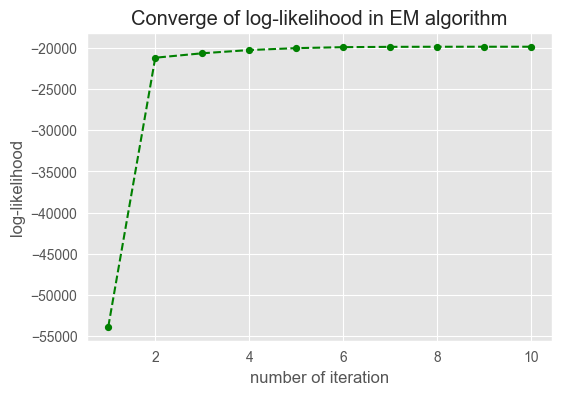

In [67]:
plt.style.use('ggplot')
plt.figure(figsize = (6,4))
plt.plot(list(range(1,11)),log_likelihood[:10],'--g',marker='o',markersize='4.2')
plt.title('Converge of log-likelihood in EM algorithm')
plt.xlabel('number of iteration')
plt.ylabel('log-likelihood')


#### mapping the mean image back to the original space

In [68]:
mean_image=eigenvectors[:,::-1][:,:4]@ mu.T
mean_image.shape

(784, 2)

In [69]:
meanvalue_image=np.mean(mnist,axis=1) #784个
std_image=np.std(mnist,axis=1) #784个
std_image.shape

(784,)

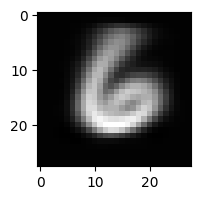

In [70]:
plt.style.use('default')
plt.figure(figsize = (2,2))
plt.imshow(np.reshape(mean_image[:,1]*std_image+meanvalue_image, (28, 28), order="F"), cmap='gray')

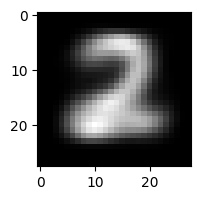

In [71]:
plt.figure(figsize = (2,2))
plt.imshow(np.reshape(mean_image[:,0]*std_image+meanvalue_image, (28, 28), order="F"), cmap='gray')

<AxesSubplot:>

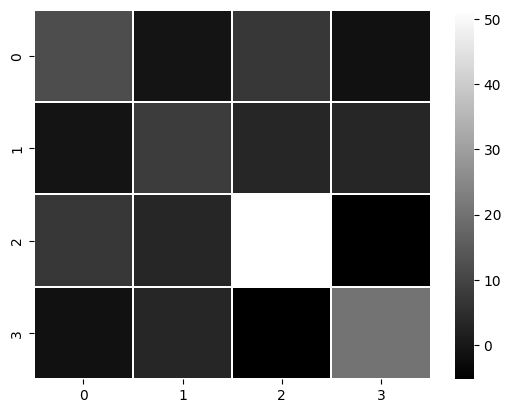

In [72]:
#visualize the covariance matrices 1
sns.heatmap(sigma[0],linewidth=0.2,cmap='gray')

<AxesSubplot:>

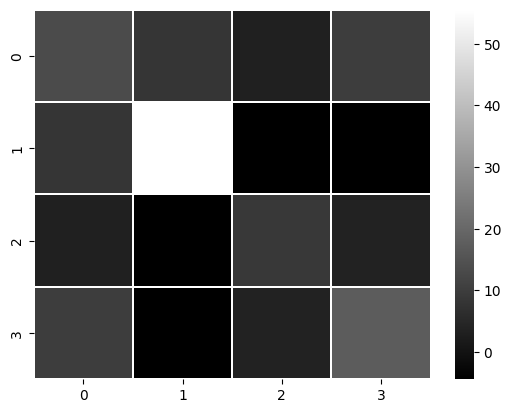

In [73]:
#visualize the covariance matrices 2
sns.heatmap(sigma[1],linewidth=0.2,cmap='gray')

In [74]:
# inverse back the covariance matrix
eigenvalue4_root=np.sqrt(eigenvalues[::-1][:4])
diag_matrix=np.diag(eigenvalue4_root)
#I didn't do whitening, so when reverse back, there is no need to use diag_matrix for squared eigenvalues
#inv_sigma0=eigenvectors[:,::-1][:,:4]@diag_matrix@sigma[0]@diag_matrix@eigenvectors[:,::-1][:,:4].T
inv_sigma0=eigenvectors[:,::-1][:,:4]@sigma[0]@eigenvectors[:,::-1][:,:4].T

<AxesSubplot:>

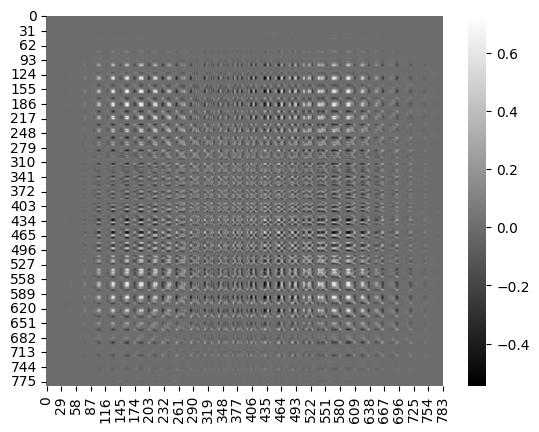

In [75]:
sns.heatmap(inv_sigma0,cmap='gray')

In [76]:
#I didn't do whitning, so when reverse back, there is no need to use diag_matrix for squared eigenvalues
#inv_sigma1=eigenvectors[:,::-1][:,:4]@diag_matrix@sigma[1]@diag_matrix@eigenvectors[:,::-1][:,:4].T
inv_sigma1=eigenvectors[:,::-1][:,:4]@sigma[1]@eigenvectors[:,::-1][:,:4].T

<AxesSubplot:>

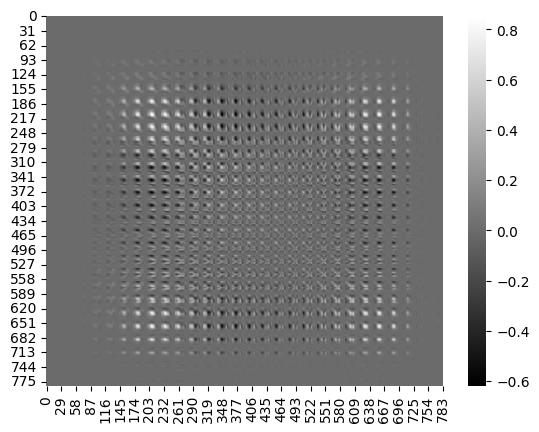

In [77]:
sns.heatmap(inv_sigma1,cmap='gray')

#### Calculate the mis-classification rate

In [78]:
label=sio.loadmat('label.mat')
label=label['trueLabel'].reshape((1990))
print(label.shape)

mask_digit2=label==2
mask_digit6=label==6
print(f'we have total {np.sum(mask_digit2)} digit 2')
print(f'we have total {np.sum(mask_digit6)} digit 6')
label

(1990,)
we have total 1032 digit 2
we have total 958 digit 6


array([2, 2, 2, ..., 6, 6, 6], dtype=uint8)

In [79]:
def assign_labels(S): 
    y=np.argmax(S,axis=1)
    return y 

In [80]:
tau_label=assign_labels(tau) 
#tau_label=0 is digit 2,tau_label=1 is digit 6

In [81]:
tau_label[tau_label==0]=2
tau_label[tau_label==1]=6
tau_label

array([2, 2, 2, ..., 6, 6, 6])

In [82]:
mask_tau2=tau_label==2
mask_tau6=tau_label==6

### First way to calculate the mis-classification rate by using my own labels!
means: out of all the digits we classified as 2, how many were truly 2

In [83]:
# mis-classification rate for digits 2 for EM
np.sum(label[mask_tau2]!=2)/np.sum(mask_tau2)

0.012219959266802444

In [84]:
# mis-classification rate for digits 6 for EM
np.sum(label[mask_tau6]!=6)/np.sum(mask_tau6)


0.061507936507936505

In [85]:
from sklearn.metrics import confusion_matrix
confusion_matrix(label, tau_label, labels=[2,6])


array([[970,  62],
       [ 12, 946]])

### Another way to calculate the mis-classification rate by using the true labels
Out of the true label of digit 2, how many real 2 has been classified by my algorithm.

In [86]:
#mis-classification rate for 2
np.sum(tau_label[mask_digit2]!=2)/np.sum(mask_digit2)

0.060077519379844964

In [87]:
#mis-classification rate for 6
np.sum(tau_label[mask_digit6]!=6)/np.sum(mask_digit6)

0.012526096033402923

### Use Kmeans from Scipy library to try on pca_mnist dataset and compare the result.
The result is GMM is better on both digites 2 and 6

In [88]:
from scipy.cluster import vq
np.random.seed(12)
centers_vq, _ = vq.kmeans(pca_mnist, 2)
kmean_label, _ = vq.vq(pca_mnist, centers_vq)
kmean_label

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [89]:
kmean_label[kmean_label==0]=2
kmean_label[kmean_label==1]=6
kmean_label

array([2, 2, 2, ..., 6, 6, 6], dtype=int32)

In [90]:
mask_kmean2=kmean_label==2
mask_kmean6=kmean_label==6

In [91]:
# mis-classification rate for digits 2 for Kmeans
np.sum(label[mask_kmean2]!=2)/np.sum(mask_kmean2)


0.031408308004052685

In [92]:
# mis-classification rate for digits 6 for Kmeans
np.sum(label[mask_kmean6]!=6)/np.sum(mask_kmean6)


0.07577268195413758

In [93]:
confusion_matrix(label, kmean_label, labels=[2,6])

array([[956,  76],
       [ 31, 927]])

### Another way to calculate the mis-classification rate by using the true labels!
Out of the true label of digit 2, how many real 2 has been classified by my algorithm.

In [94]:
np.sum(kmean_label[mask_digit2]!=2)/np.sum(mask_digit2)

0.07364341085271318

In [95]:
np.sum(kmean_label[mask_digit6]!=6)/np.sum(mask_digit6)

0.032359081419624215

### Another approach for calculating the log likelihood
### Please ignore, since the result is the same as my original one

In [96]:
#try
K=2
np.random.seed(12) #set seed
pi1 = np.random.random(K) #return 2 random number in range [0,1)
pi1 = pi1/np.sum(pi1)


np.random.seed(12)
mu1 = np.random.randn(K,4)

# form covariance
sigma1=[]

np.random.seed(12)
dummy1 = np.random.randn(4,4)
sigma1.append(dummy1@dummy1.T+np.identity(4))

In [97]:
np.random.seed(45)
dummy1 = np.random.randn(4,4)
sigma1.append(dummy1@dummy1.T+np.identity(4))

tau1 = np.full((1990, K), fill_value=0.)
 #row=i, col=k
log_likelihood1=[]
for i in range(50):
    # E-step 
    for k in range(K):
        tau1[:, k] = pi1[k] * mvn.pdf(pca_mnist, mu1[k], sigma1[k])
    likelihood=np.sum(np.log(np.sum(tau1,axis=1))) # 不同之处！在normalize tau之前，它的sum=sum   
    # calculate max log likelihood              
    log_likelihood1.append(likelihood)
              
    denominator=np.sum(tau1,axis=1).reshape((1990,1))
    tau1 = np.divide(tau1, np.tile(denominator, (1, K)))#sum tau for each i=1
    
     
    # M-step
    for k in range(K):
        # update prior
        pi1[k] = np.sum(tau1[:, k])/1990
        # update each sub-Gaussian mean
        mu1[k] = pca_mnist.T @ tau1[:,k] / np.sum(tau1[:,k])
        # update cov matrix
        sigma1[k]=(pca_mnist-mu1[k]).T@np.diag(tau1[:,k])@(pca_mnist-mu1[k])/np.sum(tau1[:,k])

Text(0, 0.5, 'log-likelihood')

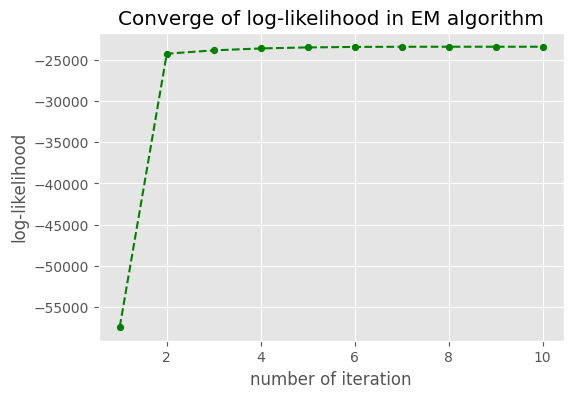

In [98]:
plt.style.use('ggplot')
plt.figure(figsize = (6,4))
plt.plot(list(range(1,11)),log_likelihood1[:10],'--g',marker='o',markersize='4.2')
plt.title('Converge of log-likelihood in EM algorithm')
plt.xlabel('number of iteration')
plt.ylabel('log-likelihood')